# 02_蒙特卡洛模拟（单介质）

本 notebook 实现：给定体积分数 f，随机布置圆柱（微构体中的导电相），并通过截断 + 并查集判断左右电极是否连通，统计导通概率 p(f)。

说明：本 notebook 假定 repo 根目录已包含 src/geometry.py、src/truncation.py、src/connectivity.py 中的必要函数。若运行在本地，请确保 Python path 包含项目根目录。

## 1.Imports 与参数设定 cell

In [1]:
# imports & setup
import os, sys
import numpy as np
import pandas as pd
import time
from multiprocessing import Pool
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False
# %matplotlib inline   # 在 notebook 中启用（去掉注释）

# 确保 repo 根在 sys.path（与 notebooks/01 一致的处理）
repo_root = os.path.dirname(os.path.dirname(os.path.abspath('__file__')))
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# ---------- 参数（可修改） ----------
L = 10000.0  # nm, box edge length
r = 30.0    # nm, cylinder radius
h = 5000.0  # nm, cylinder length
thresh = 1.8  # nm, surface-to-surface 连接阈值

# Monte Carlo 参数
f_grid = np.linspace(0.001, 0.02, 20)  # 体积分数网格（示例：0.1% ~ 2.0%）
trials_per_f = 500  # 每个 f 的独立试验次数（可调）
processes = 4  # 并行进程数（根据机器调整）。在 notebook 中多进程可能需改为 1 或运行为脚本。
seed_base = 20260812

# 输出路径
#修改输出保存路径，应该是根目录下的results文件夹  而不是notebooks文件夹下的results
out_dir = os.path.join(repo_root, 'results', 'outputs')
os.makedirs(out_dir, exist_ok=True)
out_csv = os.path.join(out_dir, 'mc_single_medium.csv')
# ----------------------------------

## 2.工具函数（体积、N 计算、随机生成圆柱）

In [2]:
def volume_cylinder(r, h):
    return np.pi * (r ** 2) * h

def compute_N_from_f(f, L, r, h):
    V_box = L ** 3
    V_cyl = volume_cylinder(r, h)
    if V_cyl <= 0:
        raise ValueError('Cylinder volume must be positive')
    N = int(round((f * V_box) / V_cyl))
    return max(0, N)

def sample_random_cylinders(N, L, r, h, seed=None):
    rng = np.random.default_rng(seed)
    centers = rng.uniform(-L/2, L/2, size=(N, 3))
    # 方向使用正态分布再归一化（球面均匀）
    dirs = rng.normal(size=(N, 3))
    norms = np.linalg.norm(dirs, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    dirs = dirs / norms
    half = (h / 2.0)
    cyls = []
    for i in range(N):
        c = centers[i]
        d = dirs[i]
        p0 = c - d * half
        p1 = c + d * half
        cyls.append(Cylinder(p0, p1, r, id=i))
    return cyls

## 3.单次试验 wrapper、Wilson 置信区间

In [3]:
def run_single_trial(args):
    # 用于 Pool.map 的 wrapper，参数打包为 (N, L, r, h, thresh, seed)
    N, L, r, h, thresh, seed = args
    cyls = sample_random_cylinders(N, L, r, h, seed=seed)
    segments = []
    for c in cyls:
        segs = split_cylinder_by_box(c, L)
        segments.extend(segs)
    connected, _uf = build_connectivity(segments, L, thresh)
    return 1 if connected else 0

def wilson_interval(k, n, z=1.96):
    # k successes in n trials, returns (low, high) for proportion
    if n == 0:
        return (0.0, 0.0)
    phat = k / n
    denom = 1 + (z**2)/n
    centre = phat + (z**2)/(2*n)
    adj = z * np.sqrt((phat*(1-phat) + (z**2)/(4*n)) / n)
    low = (centre - adj) / denom
    high = (centre + adj) / denom
    return max(0.0, low), min(1.0, high)

## 4.对单个 f 运行 Monte Carlo 的函数

In [4]:
def run_monte_carlo_for_f(f, trials, L, r, h, thresh, seed_base=0, processes=1):
    N = compute_N_from_f(f, L, r, h)
    if trials <= 0:
        return {'f': f, 'N': N, 'trials': trials, 'successes': 0, 'p_hat': 0.0, 'ci_low': 0.0, 'ci_high': 0.0}
    args_list = []
    for t in range(trials):
        seed = int(seed_base + t + int(f*1e9) % 1000000)
        args_list.append((N, L, r, h, thresh, seed))
    start = time.time()
    if processes == 1:
        results = [run_single_trial(a) for a in args_list]
    else:
        # NOTE: 在 Jupyter 中直接使用 multiprocessing.Pool 可能会遇到问题（尤其 Windows）。
        # 若要在 notebook 中并行，建议把此文件保存为脚本并以 python 运行，或在 notebook 中把 processes=1。
        with Pool(processes) as pool:
            results = pool.map(run_single_trial, args_list)
    successes = int(sum(results))
    p_hat = successes / trials
    ci_low, ci_high = wilson_interval(successes, trials)
    elapsed = time.time() - start
    return {'f': f, 'N': N, 'trials': trials, 'successes': successes, 'p_hat': p_hat, 'ci_low': ci_low, 'ci_high': ci_high, 'elapsed_s': elapsed}

## 5. 主循环：扫描 f_grid、保存结果

In [ ]:
# 扫描 f_grid（可能耗时较长）
results = []
total_start = time.time()
for f in f_grid:
    print(f'Running f={f:.6f} -> N estimation ...')
    res = run_monte_carlo_for_f(f, trials_per_f, L, r, h, thresh, seed_base=seed_base, processes=processes)
    print(f"  f={f:.6f}, N={res['N']}, successes={res['successes']}/{res['trials']}, p_hat={res['p_hat']:.4f}, time={res['elapsed_s']:.1f}s")
    results.append(res)
total_elapsed = time.time() - total_start
print(f'All done, total time: {total_elapsed:.1f}s')

# 保存结果为 CSV
df_res = pd.DataFrame(results)
df_res.to_csv(out_csv, index=False)
print('Saved results to', out_csv)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import os

repo_root = os.path.dirname(os.getcwd())
csv_path = os.path.join(repo_root, 'results/outputs/monte_carlo_results.csv')

df = pd.read_csv(csv_path)
df.head(20)

,f,N,trials,successes,p_hat,ci_low,ci_high,elapsed_s
0,0.001,71,500,500,1.0,0.992375,1.0,0.928175
1,0.002,141,500,500,1.0,0.992375,1.0,1.155437
2,0.003,212,500,500,1.0,0.992375,1.0,1.713052
3,0.004,283,500,500,1.0,0.992375,1.0,2.233311
4,0.005,354,500,500,1.0,0.992375,1.0,2.774658
5,0.006,424,500,500,1.0,0.992375,1.0,3.563938
6,0.007,495,500,500,1.0,0.992375,1.0,4.863136
7,0.008,566,500,500,1.0,0.992375,1.0,5.396955
8,0.009,637,500,500,1.0,0.992375,1.0,6.396657
9,0.010,707,500,500,1.0,0.992375,1.0,7.778270


## 6. 绘图

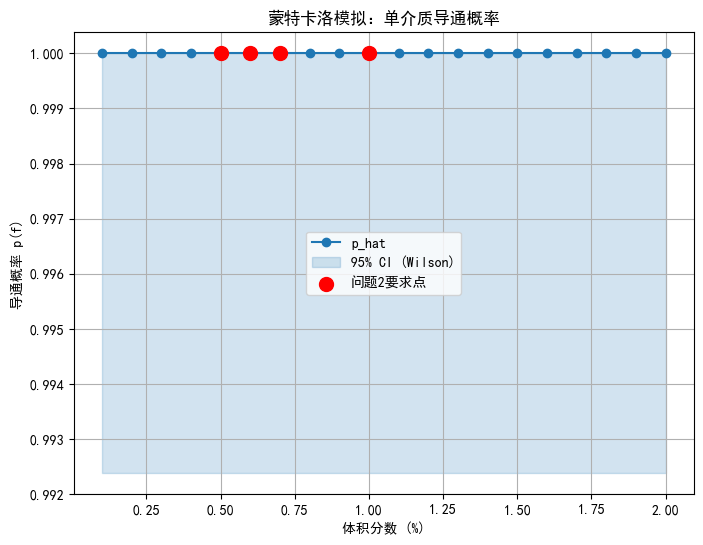

In [15]:
import matplotlib.pyplot as plt

# 绘图：p(f) 与 95% CI
plt.figure(figsize=(8,6))

# 直接用 df 里的数据
plt.plot(df['f']*100, df['p_hat'], '-o', label='p_hat')
plt.fill_between(df['f']*100, df['ci_low'], df['ci_high'], color='C0', alpha=0.2, label='95% CI (Wilson)')

# 标出问题2要求的4个点
target_f = [0.005, 0.006, 0.007, 0.010]  # 0.5%, 0.6%, 0.7%, 1.0%
target_df = df[df['f'].isin(target_f)]
plt.scatter(target_df['f']*100, target_df['p_hat'], color='red', s=100, zorder=5, label='问题2要求点')

plt.xlabel('体积分数 (%)')
plt.ylabel('导通概率 p(f)')
plt.title('蒙特卡洛模拟：单介质导通概率')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
# 绘图：p(f) 与 95% CI
if len(results) > 0:
    fs = [r['f'] for r in results]
    p_hats = [r['p_hat'] for r in results]
    lows = [r['ci_low'] for r in results]
    highs = [r['ci_high'] for r in results]
    plt.figure(figsize=(8,6))
    plt.plot(fs, p_hats, '-o', label='p_hat')
    plt.fill_between(fs, lows, highs, color='C0', alpha=0.2, label='95% CI (Wilson)')
    plt.xlabel('体积分数 f')
    plt.ylabel('导通概率 p(f)')
    plt.title('蒙特卡洛模拟：单介质导通概率')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print('No results to plot')

NameError: name 'results' is not defined

---
说明与下一步建议：
- 这是一个可运行的初始版本，重心在功能完整性而非极致性能优化。
- 对于生产级别的扫描，建议：使用更大的 trials（尤其在 p≈0.5 附近）、在 run_single_trial 中优化几何判断（KD-tree、Numba）、以及在进程级别避免频繁序列化大型对象。
- 我可以把该 notebook 提交到仓库（如果你需要我继续尝试提交请告知），或者把上面代码整理成脚本版本（scripts/run_monte_carlo.py），便于命令行并行执行（推荐用于大规模试验）。

**Cell 1：导通概率曲线（读取 CSV、绘图并标注指定点）**

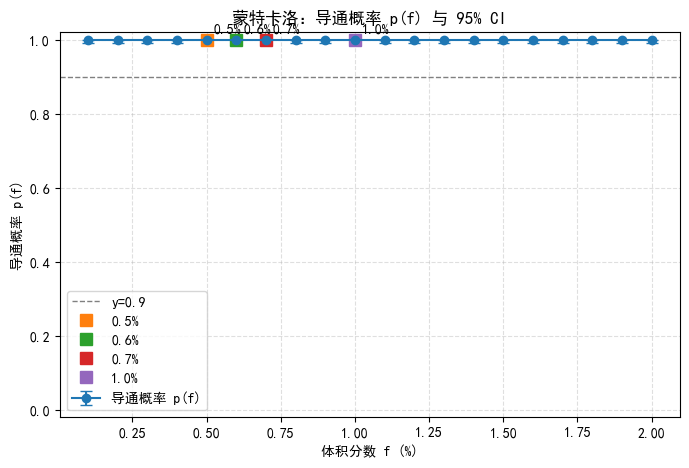

In [ ]:
# Cell: 导通概率曲线
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#out_csv = os.path.join('results', 'outputs', 'monte_carlo_results.csv')
#if not os.path.exists(out_csv):
    #raise FileNotFoundError(f"找不到结果文件: {out_csv}. 请确认脚本已将结果写到该路径。")

df = pd.read_csv(csv_path)

# 期望 df 含有列: f, p_hat, ci_low, ci_high
if not {'f', 'p_hat', 'ci_low', 'ci_high'}.issubset(df.columns):
    raise RuntimeError("结果 CSV 中缺少必要列（需要 f, p_hat, ci_low, ci_high）。请检查 CSV 格式。")

# 横坐标以百分比显示
x = df['f'].values * 100.0
y = df['p_hat'].values
ci_low = df['ci_low'].values
ci_high = df['ci_high'].values

# 在 yerr 计算之前添加
#ci_low = np.clip(ci_low, 0, 1)   # 确保下限不低于0
#ci_high = np.clip(ci_high, 0, 1) # 确保上限不高于1

# yerr 下/上
#yerr_lower = y - ci_low
#yerr_upper = ci_high - y
#yerr = np.vstack([yerr_lower, yerr_upper])

ci_low = np.clip(ci_low, 0, 1)
ci_high = np.clip(ci_high, 0, 1)
#修复：把误差值强制为非负
yerr_lower = np.maximum(y - ci_low, 0.0)
yerr_upper = np.maximum(ci_high - y, 0.0)
yerr = np.vstack([yerr_lower, yerr_upper])

plt.figure(figsize=(8,5))
plt.errorbar(x, y, yerr=yerr, fmt='o-', capsize=4, markersize=6, label='导通概率 p(f)')
plt.axhline(0.9, color='gray', linestyle='--', linewidth=1, label='y=0.9')

# 标注 4 个关注点（以百分比）
points = [0.5, 0.6, 0.7, 1.0]  # 百分比
for p in points:
    # 尝试在已有数据点上高亮，如无则在图上用垂直线标注
    mask = np.isclose(x, p, atol=1e-6)
    if mask.any():
        xi = x[mask][0]
        yi = y[mask][0]
        plt.plot(xi, yi, 's', markersize=8, label=f'{p:.1f}%')
        plt.annotate(f"{p:.1f}%", xy=(xi, yi), xytext=(5,5), textcoords='offset points')
    else:
        plt.axvline(p, color='C3', linestyle=':', linewidth=1)
        plt.text(p, 0.02, f"{p:.1f}%", rotation=90, va='bottom', ha='center', color='C3')

plt.xlabel('体积分数 f (%)')
plt.ylabel('导通概率 p(f)')
plt.ylim(-0.02, 1.02)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='best')
plt.title('蒙特卡洛：导通概率 p(f) 与 95% CI')
plt.show()

**Cell 2：2D 连通簇投影（验证 f=0.5%，寻找并展示第一个导通样本）**

说明：脚本会优先在 results/outputs 下查找是否存在已保存的单次试验样本（若你的跑脚本保存了 trial-level 文件）；若没有，则会根据在 monte_carlo 脚本中使用的 seed 生成策略，逐个重现随机样本并测试连通性，直到找到第一个导通样本（或达到最大尝试次数）。此操作只在 f = 0.005 时运行，可能花费数秒到数十秒（取决于单次连通判定成本）。你可以修改 max_attempts 以加快或延长搜索。

f=0.005 -> N=354
未在 results/outputs 中找到可直接加载的样本，开始重现试验以寻找第一个导通样本（可能需要一些时间）...
找到导通样本，seed=20260812, 在第 1 次尝试时。


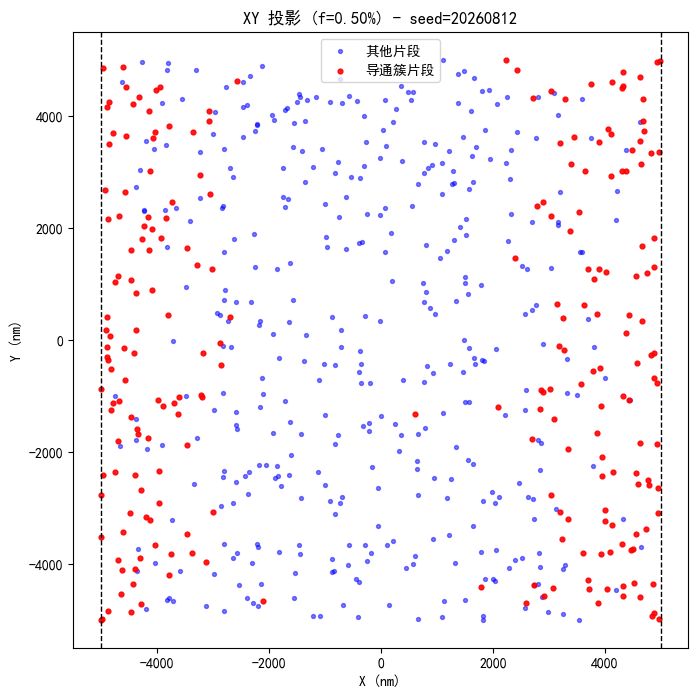

In [42]:
# Cell: 2D 连通簇投影（验证 f=0.5%）
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 导入项目函数（应与脚本一致）
from src.geometry import Cylinder
from src.truncation import split_cylinder_by_box
from src.connectivity import build_connectivity

# 参数（与模拟时一致）
L = 10000.0
r = 30.0
h = 5000.0
thresh = 1.8
seed_base = 20260812

# 目标体积分数
f_target = 0.005  # 0.5%
max_attempts = 2000  # 若无已保存样本，最多尝试的重现次数

# 读取聚合结果以获取 trials（可选）
res_csv = Path('results') / 'outputs' / 'monte_carlo_results.csv'
trials_for_f = None
if res_csv.exists():
    try:
        import pandas as pd
        df = pd.read_csv(res_csv)
        row = df[np.isclose(df['f'].values, f_target)]
        if len(row) > 0 and 'trials' in row.columns:
            trials_for_f = int(row.iloc[0]['trials'])
    except Exception:
        trials_for_f = None

# compute N
def volume_cylinder(rad, length):
    return np.pi * rad**2 * length

def compute_N_from_f(f, Lbox, rad, length):
    V_box = Lbox**3
    V_cyl = volume_cylinder(rad, length)
    return max(0, int(round((f * V_box) / V_cyl)))

N_target = compute_N_from_f(f_target, L, r, h)
print(f"f={f_target} -> N={N_target}")

# Try to find saved trial sample files under results/outputs (optional common patterns)
samples_dir = Path('results') / 'outputs'
found_sample = None
if samples_dir.exists():
    # try common filename patterns (this depends on whether you saved trial-level data)
    patterns = [
        f"*f_{f_target}*",
        f"*f{f_target}*",
        f"*f-0{int(f_target*1000)}*",  # tolerant pattern
        f"*seed*{seed_base}*",
        "*trial*",
        "*sample*"
    ]
    for pat in patterns:
        for p in samples_dir.glob(pat):
            if p.is_file():
                # attempt to load generic pickled objects (if any)
                try:
                    import pickle
                    with open(p, 'rb') as fin:
                        obj = pickle.load(fin)
                    # Heuristics: if object contains segments list, accept it
                    if isinstance(obj, dict) and 'segments' in obj:
                        found_sample = obj
                        print("Found sample in", p)
                        break
                except Exception:
                    # not a pickled sample we know how to parse
                    pass
        if found_sample is not None:
            break

# If not found, re-generate trials until the first connected sample is found
if found_sample is None:
    print("未在 results/outputs 中找到可直接加载的样本，开始重现试验以寻找第一个导通样本（可能需要一些时间）...")
    from numpy.random import default_rng

    def sample_random_cylinders(N, Lbox, rad, length, seed=None):
        rng = default_rng(seed)
        centers = rng.uniform(-Lbox/2, Lbox/2, size=(N, 3))
        dirs = rng.normal(size=(N, 3))
        norms = np.linalg.norm(dirs, axis=1, keepdims=True)
        norms[norms == 0] = 1.0
        dirs = dirs / norms
        half = length / 2.0
        cyls = []
        for i in range(N):
            c = centers[i]
            d = dirs[i]
            p0 = c - d * half
            p1 = c + d * half
            cyls.append(Cylinder(p0, p1, rad, id=i))
        return cyls

    found_segments = None
    found_seed = None
    attempts = min(max_attempts, trials_for_f if trials_for_f is not None else max_attempts)
    for t in range(attempts):
        seed = int(seed_base + t + int(abs(f_target) * 1e9) % 1000000)
        cyls = sample_random_cylinders(N_target, L, r, h, seed=seed)
        segments = []
        for c in cyls:
            segs = split_cylinder_by_box(c, L)
            segments.extend(segs)
        connected, uf = build_connectivity(segments, L, thresh)
        if connected:
            found_segments = segments
            found_seed = seed
            print(f"找到导通样本，seed={seed}, 在第 {t+1} 次尝试时。")
            break

    if found_segments is None:
        raise RuntimeError(f"在 {attempts} 次尝试内未找到导通样本。请增大 max_attempts 或检查参数。")
else:
    # 如果从文件加载了样本 dict
    # 期待 found_sample 包含 'segments' 或兼容结构
    found_segments = found_sample.get('segments')
    found_seed = found_sample.get('seed', None)
    if found_segments is None:
        raise RuntimeError("加载的样本未找到 'segments' 字段，无法继续。")

# 确定哪些片段属于导通簇
# 使用 build_connectivity 返回的 uf（若我们重现样本时已获得 uf，重用；否则重新 run）
try:
    # try to recompute uf to ensure we can query component roots
    connected, uf = build_connectivity(found_segments, L, thresh)
except Exception as e:
    # if build_connectivity is not available or fails, raise
    raise RuntimeError("调用 build_connectivity 失败，请确认实现签名：build_connectivity(segments, L, thresh) -> (connected, uf). 错误: " + str(e))

# helper: find left/right touching segment indices
left_idxs = []
right_idxs = []
eps = 1e-8
for i, s in enumerate(found_segments):
    # attempt to extract p0,p1 attributes (names may differ)
    try:
        p0 = np.array(getattr(s, 'p0'))
        p1 = np.array(getattr(s, 'p1'))
    except Exception:
        # try alternative attribute names
        p0 = np.array(getattr(s, 'a', getattr(s, 'start', None)))
        p1 = np.array(getattr(s, 'b', getattr(s, 'end', None)))
    if p0 is None or p1 is None:
        # fallback: compute center and assume not touching
        continue
    # check if segment contacts left or right electrode approximately
    x_min = min(p0[0], p1[0])
    x_max = max(p0[0], p1[0])
    if x_min - r <= -L/2 + 1e-6:
        left_idxs.append(i)
    if x_max + r >= L/2 - 1e-6:
        right_idxs.append(i)

# Determine connected root(s)
def uf_find(uf_obj, idx):
    # allow multiple UF interface styles
    if hasattr(uf_obj, 'find'):
        return uf_obj.find(idx)
    elif isinstance(uf_obj, dict):
        # assume mapping idx->root
        return uf_obj.get(idx, idx)
    elif hasattr(uf_obj, 'roots') and hasattr(uf_obj, 'parents'):
        # naive fallback
        parents = getattr(uf_obj, 'parents')
        # find root by following parent pointers
        cur = idx
        while parents[cur] != cur:
            cur = parents[cur]
        return cur
    else:
        # try attribute 'find_root' or fail
        if hasattr(uf_obj, 'find_root'):
            return uf_obj.find_root(idx)
        raise RuntimeError("无法从 uf 对象获取 find 方法，请检查 build_connectivity 的返回类型。")

left_roots = set()
right_roots = set()
for i in left_idxs:
    try:
        left_roots.add(uf_find(uf, i))
    except Exception:
        pass
for i in right_idxs:
    try:
        right_roots.add(uf_find(uf, i))
    except Exception:
        pass

intersect = left_roots & right_roots
if not intersect:
    # 若没有交集，但 build_connectivity 返回 connected=True，尝试以并查集根中查找任意被标记为 connected
    print("警告：未在并查集根中找到左右电极公共根。尝试通过 labels 标记（若 uf 提供）。")
    # fallback: mark cluster by connectivity returned earlier
    # We'll mark all roots reachable from any left root that also are connected to right via union-find equivalence
    # If still fails, just color segments by whether their root is in left-root set
    pass

# choose one connected root if exists (prefer intersection), else pick any left_root that reaches right via uf (best-effort)
if intersect:
    target_root = next(iter(intersect))
else:
    # find a root reachable from left roots that also reaches a right index by membership test
    target_root = None
    # build mapping idx->root for all segments
    roots_map = {}
    for i in range(len(found_segments)):
        try:
            roots_map[i] = uf_find(uf, i)
        except Exception:
            roots_map[i] = i
    # find candidate roots that belong to left_roots and also have some right index in same root
    for lr in left_roots:
        # check whether any right_idx has same root
        for ri in right_idxs:
            if roots_map.get(ri) == lr:
                target_root = lr
                break
        if target_root is not None:
            break
    # if still None, pick any left_root
    if target_root is None and len(left_roots) > 0:
        target_root = next(iter(left_roots))

# Collect indices in the target connected cluster
cluster_idxs = []
if target_root is not None:
    for i in range(len(found_segments)):
        try:
            if uf_find(uf, i) == target_root:
                cluster_idxs.append(i)
        except Exception:
            continue
else:
    # last resort: try to find connected cluster by running BFS on adjacency using threshold distances
    print("无法通过并查集定位导通簇，尝试用重建邻接并查找包含左右电极的簇（成本较高）。")
    # build adjacency with crude center-dist threshold for fallback
    from scipy.spatial import cKDTree
    centers = []
    radii = []
    for s in found_segments:
        # center fallback
        try:
            p0 = np.array(getattr(s, 'p0'))
            p1 = np.array(getattr(s, 'p1'))
            cen = (p0 + p1) / 2.0
            centers.append(cen)
            radii.append(getattr(s, 'r', r))
        except Exception:
            centers.append(np.array([0,0,0]))
            radii.append(r)
    centers = np.array(centers)
    tree = cKDTree(centers)
    adj = [set() for _ in range(len(found_segments))]
    for i in range(len(found_segments)):
        # neighbors within sum of bounding radii + thresh
        nbrs = tree.query_ball_point(centers[i], r= (radii[i] + max(radii) + thresh))
        for j in nbrs:
            if j <= i:
                continue
            adj[i].add(j)
            adj[j].add(i)
    # BFS from left_idxs to see which component reaches right_idxs
    visited = set()
    from collections import deque
    q = deque(left_idxs)
    for ii in left_idxs:
        visited.add(ii)
    reached_right = False
    while q:
        u = q.popleft()
        if u in right_idxs:
            reached_right = True
            break
        for v in adj[u]:
            if v not in visited:
                visited.add(v)
                q.append(v)
    if not reached_right:
        raise RuntimeError("回退邻接搜索也未能找到连接左右电极的簇。")
    cluster_idxs = list(visited)

# Extract centers for plotting and classification
centers = []
for s in found_segments:
    try:
        p0 = np.array(getattr(s, 'p0'))
        p1 = np.array(getattr(s, 'p1'))
    except Exception:
        p0 = np.array(getattr(s, 'a', getattr(s, 'start', np.array([0,0,0]))))
        p1 = np.array(getattr(s, 'b', getattr(s, 'end', np.array([0,0,0]))))
    centers.append(((p0 + p1) / 2.0))
centers = np.array(centers)

# prepare colors: red = in connected cluster, blue = others
mask_cluster = np.zeros(len(found_segments), dtype=bool)
for idx in cluster_idxs:
    if 0 <= idx < len(mask_cluster):
        mask_cluster[idx] = True

plt.figure(figsize=(8,8))
plt.scatter(centers[~mask_cluster,0], centers[~mask_cluster,1], s=8, color='blue', alpha=0.5, label='其他片段')
plt.scatter(centers[mask_cluster,0], centers[mask_cluster,1], s=12, color='red', alpha=0.9, label='导通簇片段')
plt.axvline(-L/2, color='k', linestyle='--', linewidth=1)
plt.axvline( L/2, color='k', linestyle='--', linewidth=1)
plt.xlabel('X (nm)')
plt.ylabel('Y (nm)')
plt.title(f'XY 投影 (f={f_target*100:.2f}%) - seed={found_seed}')
plt.gca().set_aspect('equal', 'box')
plt.legend()
plt.show()

**注意**  
1. 这里画的是XY 投影，3D 中的导通路径可能是通过 z 方向连接的，投影后看起来会断开；  
2. 图里只绘制了片段的中心点/投影点（或投影后的线段），并不能完全反映 3D 上是否存在连续接触；  
3. **导通簇片段在 XY 投影上可能本身就不是一条“连成线”的路径，尤其是当路径在 z 方向上跳跃时，二维投影会显得散乱。**

接触左边界片段数: 85
接触右边界片段数: 85
左电极根数: 1, 右电极根数: 1, 公共根数: 1
导通簇包含片段数: 227
导通簇 X 范围: [-5000.0, 5000.0] nm
是否接触左边界: True
是否接触右边界: True


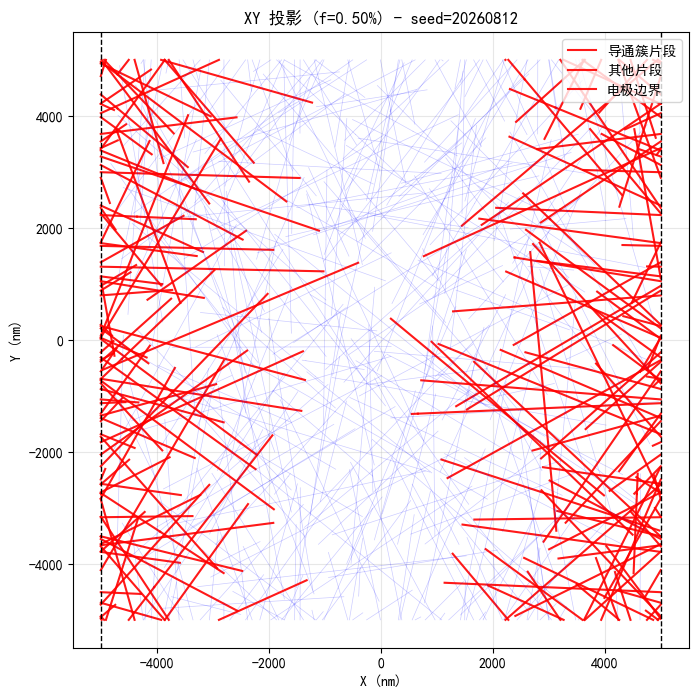

In [43]:
# helper: find left/right touching segment indices
left_idxs = []
right_idxs = []
eps = 1e-6
half_L = L / 2.0

for i, s in enumerate(found_segments):
    try:
        p0 = np.array(getattr(s, 'p0'))
        p1 = np.array(getattr(s, 'p1'))
    except Exception:
        p0 = np.array(getattr(s, 'a', getattr(s, 'start', None)))
        p1 = np.array(getattr(s, 'b', getattr(s, 'end', None)))
    if p0 is None or p1 is None:
        continue

    if abs(p0[0] + half_L) < eps or abs(p1[0] + half_L) < eps:
        left_idxs.append(i)
    if abs(p0[0] - half_L) < eps or abs(p1[0] - half_L) < eps:
        right_idxs.append(i)

print(f"接触左边界片段数: {len(left_idxs)}")
print(f"接触右边界片段数: {len(right_idxs)}")

# Determine connected root(s)
def uf_find(uf_obj, idx):
    if hasattr(uf_obj, 'find'):
        return uf_obj.find(idx)
    elif isinstance(uf_obj, dict):
        return uf_obj.get(idx, idx)
    elif hasattr(uf_obj, 'roots') and hasattr(uf_obj, 'parents'):
        parents = getattr(uf_obj, 'parents')
        cur = idx
        while parents[cur] != cur:
            cur = parents[cur]
        return cur
    elif hasattr(uf_obj, 'find_root'):
        return uf_obj.find_root(idx)
    raise RuntimeError("无法从 uf 对象获取 find 方法，请检查 build_connectivity 的返回类型。")

left_roots = set()
right_roots = set()
for i in left_idxs:
    try:
        left_roots.add(uf_find(uf, i))
    except Exception:
        pass
for i in right_idxs:
    try:
        right_roots.add(uf_find(uf, i))
    except Exception:
        pass

intersect = left_roots & right_roots
print(f"左电极根数: {len(left_roots)}, 右电极根数: {len(right_roots)}, 公共根数: {len(intersect)}")

if not intersect:
    print("警告：未在并查集根中找到左右电极公共根。请检查 build_connectivity 是否正确返回 connected=True。")

if intersect:
    target_root = next(iter(intersect))
else:
    target_root = None
    roots_map = {}
    for i in range(len(found_segments)):
        try:
            roots_map[i] = uf_find(uf, i)
        except Exception:
            roots_map[i] = i
    for lr in left_roots:
        for ri in right_idxs:
            if roots_map.get(ri) == lr:
                target_root = lr
                break
        if target_root is not None:
            break
    if target_root is None and len(left_roots) > 0:
        target_root = next(iter(left_roots))

cluster_idxs = []
if target_root is not None:
    for i in range(len(found_segments)):
        try:
            if uf_find(uf, i) == target_root:
                cluster_idxs.append(i)
        except Exception:
            continue
else:
    print("无法确定 target_root，使用 BFS 回退查找。")
    from scipy.spatial import cKDTree
    centers = []
    radii = []
    for s in found_segments:
        try:
            p0 = np.array(getattr(s, 'p0'))
            p1 = np.array(getattr(s, 'p1'))
            centers.append((p0 + p1) / 2.0)
            radii.append(getattr(s, 'r', r))
        except Exception:
            centers.append(np.array([0.0, 0.0, 0.0]))
            radii.append(r)
    centers = np.array(centers)
    tree = cKDTree(centers)
    adj = [set() for _ in range(len(found_segments))]
    for i in range(len(found_segments)):
        nbrs = tree.query_ball_point(centers[i], r=(radii[i] + max(radii) + thresh))
        for j in nbrs:
            if j <= i:
                continue
            adj[i].add(j)
            adj[j].add(i)

    from collections import deque
    visited = set(left_idxs)
    q = deque(left_idxs)
    reached_right = False
    while q:
        u = q.popleft()
        if u in right_idxs:
            reached_right = True
            break
        for v in adj[u]:
            if v not in visited:
                visited.add(v)
                q.append(v)
    if not reached_right:
        raise RuntimeError("回退邻接搜索未能找到连接左右电极的簇。")
    cluster_idxs = list(visited)

print(f"导通簇包含片段数: {len(cluster_idxs)}")

cluster_x = []
for idx in cluster_idxs:
    try:
        p0 = np.array(getattr(found_segments[idx], 'p0'))
        p1 = np.array(getattr(found_segments[idx], 'p1'))
    except Exception:
        p0 = np.array(getattr(found_segments[idx], 'a', getattr(found_segments[idx], 'start', np.array([0,0,0]))))
        p1 = np.array(getattr(found_segments[idx], 'b', getattr(found_segments[idx], 'end', np.array([0,0,0]))))
    cluster_x.extend([p0[0], p1[0]])

if cluster_x:
    print(f"导通簇 X 范围: [{min(cluster_x):.1f}, {max(cluster_x):.1f}] nm")
    print(f"是否接触左边界: {min(cluster_x) <= -half_L + eps}")
    print(f"是否接触右边界: {max(cluster_x) >= half_L - eps}")

plt.figure(figsize=(8,8))
for i, s in enumerate(found_segments):
    try:
        p0 = np.array(getattr(s, 'p0'))
        p1 = np.array(getattr(s, 'p1'))
    except Exception:
        p0 = np.array(getattr(s, 'a', getattr(s, 'start', np.array([0,0,0]))))
        p1 = np.array(getattr(s, 'b', getattr(s, 'end', np.array([0,0,0]))))
    xs = [p0[0], p1[0]]
    ys = [p0[1], p1[1]]
    if i in cluster_idxs:
        plt.plot(xs, ys, color='red', linewidth=1.5, alpha=0.9)
    else:
        plt.plot(xs, ys, color='blue', linewidth=0.5, alpha=0.2)

plt.axvline(-half_L, color='k', linestyle='--', linewidth=1, label='电极平面')
plt.axvline(half_L, color='k', linestyle='--', linewidth=1)
plt.xlabel('X (nm)')
plt.ylabel('Y (nm)')
plt.title(f'XY 投影 (f={f_target*100:.2f}%) - seed={found_seed}')
plt.gca().set_aspect('equal', 'box')
plt.grid(True, alpha=0.3)
plt.legend(['导通簇片段', '其他片段', '电极边界'])
plt.show()

**Cell 3：3D 可视化（只显示导通路径上的片段并绘制立方体边界）**

说明：使用 matplotlib 的 3D 绘图（内置，便于无外部依赖）。若你更喜欢 plotly，我也可以提供 plotly 版本（交互式）。

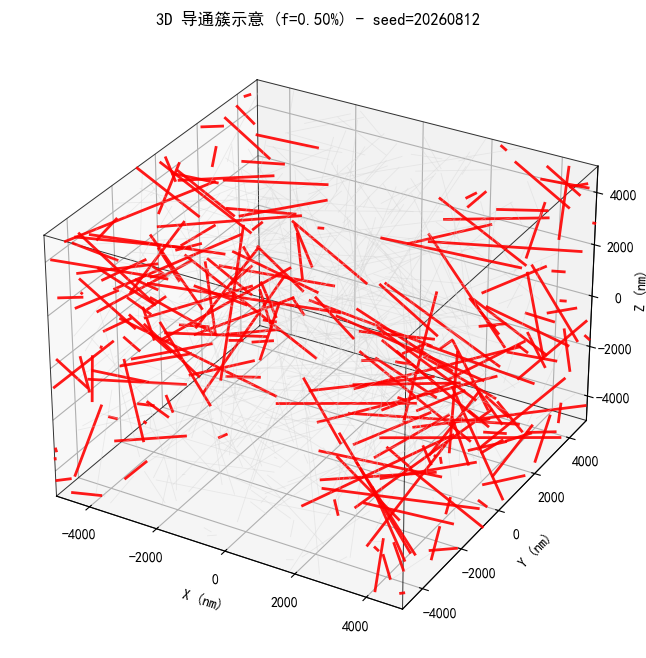

In [29]:
# Cell: 3D 可视化（matplotlib）
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# 使用前一步得到的 found_segments, cluster_idxs
# 若不存在，请先运行上一个 cell

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

# 绘成立方体边界框（cube from -L/2..L/2）
L_half = L/2.0
# 8 corners
corners = np.array([
    [-L_half, -L_half, -L_half],
    [ L_half, -L_half, -L_half],
    [ L_half,  L_half, -L_half],
    [-L_half,  L_half, -L_half],
    [-L_half, -L_half,  L_half],
    [ L_half, -L_half,  L_half],
    [ L_half,  L_half,  L_half],
    [-L_half,  L_half,  L_half],
])
# edges as pairs of corner indices
edges = [
    (0,1),(1,2),(2,3),(3,0),
    (4,5),(5,6),(6,7),(7,4),
    (0,4),(1,5),(2,6),(3,7)
]
for (i,j) in edges:
    xs = [corners[i,0], corners[j,0]]
    ys = [corners[i,1], corners[j,1]]
    zs = [corners[i,2], corners[j,2]]
    ax.plot(xs, ys, zs, color='k', linewidth=0.7, alpha=0.8)

# Plot all segments lightly (optional)
plot_all = True
if plot_all:
    for i, s in enumerate(found_segments):
        try:
            p0 = np.array(getattr(s, 'p0'))
            p1 = np.array(getattr(s, 'p1'))
        except Exception:
            p0 = np.array(getattr(s, 'a', getattr(s, 'start', np.array([0,0,0]))))
            p1 = np.array(getattr(s, 'b', getattr(s, 'end', np.array([0,0,0]))))
        # color and linewidth
        if i in cluster_idxs:
            c = 'red'
            lw = 2.0
            alpha = 0.9
        else:
            c = 'lightgray'
            lw = 0.6
            alpha = 0.4
        ax.plot([p0[0], p1[0]], [p0[1], p1[1]], [p0[2], p1[2]], color=c, linewidth=lw, alpha=alpha)

# adjust view
ax.set_xlabel('X (nm)')
ax.set_ylabel('Y (nm)')
ax.set_zlabel('Z (nm)',labelpad=0.8)  #zlabelpad 调整标签与坐标轴的距离,解决z轴标签被遮挡的问题
ax.set_title(f"3D 导通簇示意 (f={f_target*100:.2f}%) - seed={found_seed}")

# set equal aspect ratio (approximation)
max_range = np.array([corners[:,0].max()-corners[:,0].min(),
                      corners[:,1].max()-corners[:,1].min(),
                      corners[:,2].max()-corners[:,2].min()]).max() / 2.0
mid_x = (corners[:,0].max()+corners[:,0].min()) * 0.5
mid_y = (corners[:,1].max()+corners[:,1].min()) * 0.5
mid_z = (corners[:,2].max()+corners[:,2].min()) * 0.5
ax.set_xlim(mid_x - max_range, mid_x + max_range)
ax.set_ylim(mid_y - max_range, mid_y + max_range)
ax.set_zlim(mid_z - max_range, mid_z + max_range)


plt.show()